# Module 4 — Notebook 1: Customer Feature Engineering

**Objective:** transform the raw customer profile table and POS transaction table into one clean customer-level feature matrix for customer segmentation.

**Inputs**
- `customers.csv`
- `enterprise_pos_dataset.csv`

**Main output**
- `outputs/module4/features/customer_features.csv`

**Report visuals**
- Saved in `outputs/module4/figures/`

This notebook prepares the features required by Notebook 2 for:
1. RFM rule-based segmentation
2. K-Means behavioral clustering
3. Hierarchical clustering validation
4. Hybrid RFM + behavioral segmentation

## 0. Setup

In [29]:
import json
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_DIR = '../datasets'
CUSTOMERS_PATH = '../datasets/customers.csv'
TRANSACTIONS_PATH = '../datasets/enterprise_pos_dataset.csv'

OUTPUT_DIR = '../Module 4'
FEATURE_DIR = '../Module 4'
FIGURE_DIR = '../Module 4/figures'
REPORT_DIR = '../Module 4'

for d in [FEATURE_DIR, FIGURE_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42

print("Output directory:", OUTPUT_DIR)

Output directory: ../Module 4


## 1. Load and validate data

The transaction file uses a pipe separator (`|`), so it is loaded with `sep='|'`.

In [30]:
customers = pd.read_csv(CUSTOMERS_PATH)
transactions = pd.read_csv(TRANSACTIONS_PATH, sep="|")

print("Customers shape:", customers.shape)
print("Transactions shape:", transactions.shape)

display(customers.head())
display(transactions.head())

Customers shape: (10000, 10)
Transactions shape: (178839, 17)


,customer_id,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits
0,5485,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2,2
1,7761,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4,4
2,1774,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5,5
3,3417,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6,6
4,447,regular,premium,morning,any,medium,Cafe,"Appetizer,Food,Dessert",22,16


,order_details_id,order_id,order_date,order_time,item_name,category,price,restaurant_type,item_id,customer_id,cashier_id,payment_method,table_number,is_voided,void_reason,discount_pct,line_total
0,500000,100000,2023-01-01,07:30 AM,Oatmeal with Berries,Food,5.50,Cafe,80,520,C02,card,12.0,False,NaN,0.0,5.50
1,500001,100000,2023-01-01,07:30 AM,Cold Brew Coffee,Beverage,4.50,Cafe,35,520,C02,card,12.0,False,NaN,0.0,4.50
2,500002,100000,2023-01-01,07:30 AM,Fruit Smoothie,Beverage,6.50,Cafe,50,520,C02,card,12.0,False,NaN,0.0,6.50
3,500003,100001,2023-01-01,08:00 AM,Almond Croissant,Bakery,4.25,Cafe,4,6381,C03,cash,21.0,False,NaN,0.0,4.25
4,500004,100001,2023-01-01,08:00 AM,Everything Bagel with Cream Cheese,Bakery,4.50,Cafe,46,6381,C03,cash,21.0,False,NaN,0.0,4.50


In [31]:
# Basic schema validation
required_customer_cols = {
    "customer_id", "archetype", "price_tier", "time_preference", "day_preference",
    "basket_size_bias", "preferred_sections", "preferred_categories",
    "expected_visits", "actual_visits"
}

required_transaction_cols = {
    "order_details_id", "order_id", "order_date", "order_time", "item_name",
    "category", "price", "restaurant_type", "item_id", "customer_id",
    "cashier_id", "payment_method", "table_number", "is_voided",
    "discount_pct", "line_total"
}

missing_customer_cols = required_customer_cols - set(customers.columns)
missing_transaction_cols = required_transaction_cols - set(transactions.columns)

assert not missing_customer_cols, f"Missing customer columns: {missing_customer_cols}"
assert not missing_transaction_cols, f"Missing transaction columns: {missing_transaction_cols}"

print("Customer columns valid.")
print("Transaction columns valid.")

print("Customer missing values:")
display(customers.isna().sum().sort_values(ascending=False).head(20))

print("Transaction missing values:")
display(transactions.isna().sum().sort_values(ascending=False).head(20))

Customer columns valid.
Transaction columns valid.
Customer missing values:


customer_id             0
archetype               0
price_tier              0
time_preference         0
day_preference          0
basket_size_bias        0
preferred_sections      0
preferred_categories    0
expected_visits         0
actual_visits           0
dtype: int64

Transaction missing values:


void_reason         175878
table_number         53236
order_details_id         0
customer_id              0
discount_pct             0
is_voided                0
payment_method           0
cashier_id               0
item_id                  0
order_id                 0
restaurant_type          0
price                    0
category                 0
item_name                0
order_time               0
order_date               0
line_total               0
dtype: int64

In [32]:
# Convert important columns to correct dtypes
transactions["order_date"] = pd.to_datetime(transactions["order_date"], errors="coerce")
transactions["order_datetime"] = pd.to_datetime(
    transactions["order_date"].dt.strftime("%Y-%m-%d") + " " + transactions["order_time"].astype(str),
    errors="coerce"
)

bool_map = {"True": True, "False": False, True: True, False: False}
transactions["is_voided"] = transactions["is_voided"].map(bool_map).fillna(False).astype(bool)

numeric_cols = ["price", "discount_pct", "line_total", "customer_id", "order_id", "item_id"]
for col in numeric_cols:
    transactions[col] = pd.to_numeric(transactions[col], errors="coerce")

customers["customer_id"] = pd.to_numeric(customers["customer_id"], errors="coerce")

print("Date range:", transactions["order_date"].min(), "to", transactions["order_date"].max())
print("Unique customers in customer profile table:", customers["customer_id"].nunique())
print("Unique customers in transactions:", transactions["customer_id"].nunique())
print("Unique orders:", transactions["order_id"].nunique())
print("Unique items:", transactions["item_id"].nunique())

Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Unique customers in customer profile table: 10000
Unique customers in transactions: 9991
Unique orders: 63049
Unique items: 122


## 2. Remove voided transactions

Voided lines are excluded from RFM and behavioral metrics because they do not represent completed sales.

In [33]:
void_summary = transactions["is_voided"].value_counts(dropna=False).rename_axis("is_voided").reset_index(name="line_count")
display(void_summary)

valid_tx = transactions.loc[~transactions["is_voided"]].copy()

print("Original transaction lines:", len(transactions))
print("Valid non-voided transaction lines:", len(valid_tx))
print("Removed voided lines:", len(transactions) - len(valid_tx))
print("Valid unique orders:", valid_tx["order_id"].nunique())
print("Valid unique customers:", valid_tx["customer_id"].nunique())

,is_voided,line_count
0,False,175878
1,True,2961


Original transaction lines: 178839
Valid non-voided transaction lines: 175878
Removed voided lines: 2961
Valid unique orders: 61986
Valid unique customers: 9960


## 3. Build order-level table

The raw dataset is line-level. For customer segmentation, we first aggregate it into order-level behavior.

In [34]:
# Time features at line level before grouping
valid_tx["order_hour"] = valid_tx["order_datetime"].dt.hour
valid_tx["day_of_week"] = valid_tx["order_datetime"].dt.day_name()
valid_tx["day_of_week_num"] = valid_tx["order_datetime"].dt.dayofweek
valid_tx["is_weekend"] = valid_tx["day_of_week_num"].isin([5, 6]).astype(int)
valid_tx["month"] = valid_tx["order_datetime"].dt.month
valid_tx["year"] = valid_tx["order_datetime"].dt.year

def meal_period(hour):
    if pd.isna(hour):
        return "unknown"
    if 6 <= hour < 11:
        return "morning"
    if 11 <= hour < 16:
        return "lunch"
    if 16 <= hour < 23:
        return "dinner"
    return "late_night"

valid_tx["meal_period"] = valid_tx["order_hour"].apply(meal_period)
valid_tx["discount_amount_est"] = valid_tx["price"] * (valid_tx["discount_pct"] / 100.0)

order_level = (
    valid_tx
    .groupby("order_id")
    .agg(
        customer_id=("customer_id", "first"),
        order_datetime=("order_datetime", "first"),
        order_date=("order_date", "first"),
        order_hour=("order_hour", "first"),
        day_of_week=("day_of_week", "first"),
        day_of_week_num=("day_of_week_num", "first"),
        is_weekend=("is_weekend", "first"),
        meal_period=("meal_period", "first"),
        payment_method=("payment_method", "first"),
        table_number=("table_number", "first"),
        order_total=("line_total", "sum"),
        order_avg_item_price=("price", "mean"),
        order_discount_pct_mean=("discount_pct", "mean"),
        order_discount_amount_est=("discount_amount_est", "sum"),
        n_lines=("order_details_id", "count"),
        n_unique_items=("item_id", "nunique"),
        n_categories=("category", "nunique"),
        n_restaurant_types=("restaurant_type", "nunique")
    )
    .reset_index()
)

order_level["has_discount"] = (order_level["order_discount_pct_mean"] > 0).astype(int)
order_level["basket_size"] = order_level["n_lines"]

print("Order-level table shape:", order_level.shape)
display(order_level.head())

Order-level table shape: (61986, 21)


,order_id,customer_id,order_datetime,order_date,order_hour,day_of_week,day_of_week_num,is_weekend,meal_period,payment_method,table_number,order_total,order_avg_item_price,order_discount_pct_mean,order_discount_amount_est,n_lines,n_unique_items,n_categories,n_restaurant_types,has_discount,basket_size
0,100000,520,2023-01-01 07:30:00,2023-01-01,7,Sunday,6,1,morning,card,12.0,16.50,5.500,0.0,0.0,3,3,2,1,0,3
1,100001,6381,2023-01-01 08:00:00,2023-01-01,8,Sunday,6,1,morning,cash,21.0,8.75,4.375,0.0,0.0,2,2,1,1,0,2
2,100002,6422,2023-01-01 08:00:00,2023-01-01,8,Sunday,6,1,morning,cash,24.0,15.50,3.875,0.0,0.0,4,4,2,1,0,4
3,100003,3973,2023-01-01 08:30:00,2023-01-01,8,Sunday,6,1,morning,card,22.0,11.25,3.750,0.0,0.0,3,3,2,1,0,3
4,100004,4622,2023-01-01 08:00:00,2023-01-01,8,Sunday,6,1,morning,cash,7.0,7.25,3.625,0.0,0.0,2,2,1,1,0,2


## 4. Compute RFM features

RFM measures customer lifecycle and value:
- **Recency:** days since the customer's last order
- **Frequency:** number of completed orders
- **Monetary:** total completed spending

In [35]:
reference_date = valid_tx["order_datetime"].max() + pd.Timedelta(days=1)
print("Reference date for recency:", reference_date)

rfm = (
    order_level
    .groupby("customer_id")
    .agg(
        last_order_date=("order_datetime", "max"),
        first_order_date=("order_datetime", "min"),
        frequency=("order_id", "nunique"),
        monetary=("order_total", "sum")
    )
    .reset_index()
)

rfm["recency"] = (reference_date - rfm["last_order_date"]).dt.days
rfm["customer_tenure_days"] = (rfm["last_order_date"] - rfm["first_order_date"]).dt.days.clip(lower=0)
rfm["monetary_per_order"] = rfm["monetary"] / rfm["frequency"].replace(0, np.nan)

# Robust quintile scoring. Higher score is better. Recency is reversed.
def quintile_score(series, reverse=False):
    ranked = series.rank(method="first", ascending=not reverse)
    try:
        return pd.qcut(ranked, 5, labels=[1, 2, 3, 4, 5]).astype(int)
    except ValueError:
        return pd.cut(ranked, 5, labels=[1, 2, 3, 4, 5], include_lowest=True).astype(int)

rfm["R_score"] = quintile_score(rfm["recency"], reverse=True)
rfm["F_score"] = quintile_score(rfm["frequency"], reverse=False)
rfm["M_score"] = quintile_score(rfm["monetary"], reverse=False)
rfm["rfm_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
rfm["rfm_code"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

print("RFM shape:", rfm.shape)
display(rfm.head())
display(rfm[["recency", "frequency", "monetary", "rfm_score"]].describe())

Reference date for recency: 2026-01-01 21:00:00
RFM shape: (9960, 13)


,customer_id,last_order_date,first_order_date,frequency,monetary,recency,customer_tenure_days,monetary_per_order,R_score,F_score,M_score,rfm_score,rfm_code
0,0,2025-12-23 18:30:00,2023-01-26 07:00:00,94,15189.00,9,1062,161.585106,5,5,5,15,555
1,1,2025-11-23 19:00:00,2023-02-16 13:00:00,19,355.55,39,1011,18.713158,5,5,5,15,555
2,2,2025-11-08 12:00:00,2023-02-24 12:00:00,15,317.92,54,988,21.194667,5,5,5,15,555
3,3,2025-10-11 20:30:00,2023-06-25 19:00:00,25,592.20,82,839,23.688000,4,5,5,14,455
4,4,2025-12-31 20:00:00,2023-01-21 19:30:00,20,739.45,1,1075,36.972500,5,5,5,15,555


,recency,frequency,monetary,rfm_score
count,9960.000000,9960.000000,9960.000000,9960.000000
mean,381.063454,6.223494,160.831505,9.000000
std,323.524204,5.874841,228.896083,3.896853
min,1.000000,1.000000,0.950000,3.000000
25%,88.000000,2.000000,41.500000,6.000000
50%,309.000000,4.000000,96.050000,9.000000
75%,618.000000,9.000000,215.910000,12.000000
max,1096.000000,94.000000,15189.000000,15.000000


## 5. Compute basket metrics

In [36]:
basket_features = (
    order_level
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        avg_order_value=("order_total", "mean"),
        median_order_value=("order_total", "median"),
        max_order_value=("order_total", "max"),
        avg_basket_size=("basket_size", "mean"),
        median_basket_size=("basket_size", "median"),
        avg_unique_items_per_order=("n_unique_items", "mean"),
        avg_categories_per_order=("n_categories", "mean"),
        avg_item_price=("order_avg_item_price", "mean")
    )
    .reset_index()
)

display(basket_features.head())

,customer_id,total_orders,avg_order_value,median_order_value,max_order_value,avg_basket_size,median_basket_size,avg_unique_items_per_order,avg_categories_per_order,avg_item_price
0,0,94,161.585106,133.5,400.00,18.148936,18.0,11.053191,4.478723,8.868839
1,1,19,18.713158,21.0,41.00,2.368421,2.0,2.368421,1.736842,7.984211
2,2,15,21.194667,20.5,39.52,3.000000,3.0,3.000000,2.200000,7.083889
3,3,25,23.688000,22.0,47.50,2.880000,3.0,2.880000,2.320000,8.704667
4,4,20,36.972500,30.5,78.00,3.700000,4.0,3.700000,2.650000,10.535417


## 6. Compute discount and payment behavior

In [37]:
discount_features = (
    order_level
    .groupby("customer_id")
    .agg(
        avg_discount_pct=("order_discount_pct_mean", "mean"),
        discount_order_rate=("has_discount", "mean"),
        total_discount_amount_est=("order_discount_amount_est", "sum")
    )
    .reset_index()
)

payment_pivot = pd.crosstab(order_level["customer_id"], order_level["payment_method"], normalize="index")
payment_pivot.columns = [f"payment_share_{c}" for c in payment_pivot.columns]
payment_pivot = payment_pivot.reset_index()

preferred_payment = (
    order_level
    .groupby(["customer_id", "payment_method"])
    .size()
    .reset_index(name="n")
    .sort_values(["customer_id", "n"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"payment_method": "preferred_payment_method"})[["customer_id", "preferred_payment_method"]]
)

payment_features = payment_pivot.merge(preferred_payment, on="customer_id", how="left")

display(discount_features.head())
display(payment_features.head())

,customer_id,avg_discount_pct,discount_order_rate,total_discount_amount_est
0,0,0.000000,0.000000,0.000
1,1,2.368421,0.157895,4.950
2,2,6.333333,0.200000,11.575
3,3,1.200000,0.080000,8.800
4,4,1.500000,0.100000,17.550


,customer_id,payment_share_card,payment_share_cash,payment_share_mobile,preferred_payment_method
0,0,0.000000,1.000000,0.000000,cash
1,1,0.421053,0.421053,0.157895,card
2,2,0.466667,0.466667,0.066667,card
3,3,0.640000,0.200000,0.160000,card
4,4,0.450000,0.450000,0.100000,card


## 7. Compute time and day behavior

In [38]:
time_features = (
    order_level
    .groupby("customer_id")
    .agg(
        avg_order_hour=("order_hour", "mean"),
        std_order_hour=("order_hour", "std"),
        weekend_order_rate=("is_weekend", "mean")
    )
    .reset_index()
)

day_pivot = pd.crosstab(order_level["customer_id"], order_level["day_of_week"], normalize="index")
day_pivot.columns = ["dow_share_" + str(c).lower() for c in day_pivot.columns]
day_pivot = day_pivot.reset_index()

meal_pivot = pd.crosstab(order_level["customer_id"], order_level["meal_period"], normalize="index")
meal_pivot.columns = ["meal_share_" + str(c).lower() for c in meal_pivot.columns]
meal_pivot = meal_pivot.reset_index()

preferred_meal = (
    order_level
    .groupby(["customer_id", "meal_period"])
    .size()
    .reset_index(name="n")
    .sort_values(["customer_id", "n"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"meal_period": "dominant_meal_period"})[["customer_id", "dominant_meal_period"]]
)

preferred_day = (
    order_level
    .groupby(["customer_id", "day_of_week"])
    .size()
    .reset_index(name="n")
    .sort_values(["customer_id", "n"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"day_of_week": "dominant_day_of_week"})[["customer_id", "dominant_day_of_week"]]
)

time_behavior = (
    time_features
    .merge(day_pivot, on="customer_id", how="left")
    .merge(meal_pivot, on="customer_id", how="left")
    .merge(preferred_meal, on="customer_id", how="left")
    .merge(preferred_day, on="customer_id", how="left")
)

display(time_behavior.head())

,customer_id,avg_order_hour,std_order_hour,weekend_order_rate,dow_share_friday,dow_share_monday,dow_share_saturday,dow_share_sunday,dow_share_thursday,dow_share_tuesday,dow_share_wednesday,meal_share_dinner,meal_share_late_night,meal_share_lunch,meal_share_morning,dominant_meal_period,dominant_day_of_week
0,0,16.191489,4.693341,0.308511,0.148936,0.106383,0.117021,0.191489,0.127660,0.127660,0.180851,0.648936,0.0,0.180851,0.170213,dinner,Sunday
1,1,18.526316,2.245203,0.210526,0.210526,0.105263,0.105263,0.105263,0.210526,0.210526,0.052632,0.894737,0.0,0.105263,0.000000,dinner,Friday
2,2,12.866667,2.559762,0.400000,0.200000,0.066667,0.133333,0.266667,0.133333,0.066667,0.133333,0.133333,0.0,0.866667,0.000000,lunch,Sunday
3,3,19.320000,1.519868,0.440000,0.160000,0.040000,0.240000,0.200000,0.120000,0.040000,0.200000,0.960000,0.0,0.040000,0.000000,dinner,Saturday
4,4,19.000000,2.492093,0.450000,0.200000,0.050000,0.150000,0.300000,0.100000,0.100000,0.100000,0.950000,0.0,0.000000,0.050000,dinner,Sunday


## 8. Compute category and restaurant-type preferences

In this dataset, `restaurant_type` acts like a section/cuisine family: Cafe, American, Italian, Japanese, Mexican, Healthy_Vegan, Steakhouse.

In [39]:
# Spending shares by category
category_spend = valid_tx.pivot_table(
    index="customer_id", columns="category", values="line_total", aggfunc="sum", fill_value=0
)
category_spend_share = category_spend.div(category_spend.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
category_spend_share.columns = [f"category_share_{str(c).lower()}" for c in category_spend_share.columns]
category_spend_share = category_spend_share.reset_index()

# Spending shares by restaurant_type / section
section_spend = valid_tx.pivot_table(
    index="customer_id", columns="restaurant_type", values="line_total", aggfunc="sum", fill_value=0
)
section_spend_share = section_spend.div(section_spend.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
section_spend_share.columns = [f"section_share_{str(c).lower()}" for c in section_spend_share.columns]
section_spend_share = section_spend_share.reset_index()

# Diversity features
preference_diversity = (
    valid_tx
    .groupby("customer_id")
    .agg(
        unique_items_bought=("item_id", "nunique"),
        unique_categories_bought=("category", "nunique"),
        unique_sections_bought=("restaurant_type", "nunique")
    )
    .reset_index()
)

# Dominant category and section by spending
dominant_category = (
    valid_tx
    .groupby(["customer_id", "category"])["line_total"].sum()
    .reset_index(name="spend")
    .sort_values(["customer_id", "spend"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"category": "dominant_category"})[["customer_id", "dominant_category"]]
)

dominant_section = (
    valid_tx
    .groupby(["customer_id", "restaurant_type"])["line_total"].sum()
    .reset_index(name="spend")
    .sort_values(["customer_id", "spend"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"restaurant_type": "dominant_section"})[["customer_id", "dominant_section"]]
)

preference_features = (
    category_spend_share
    .merge(section_spend_share, on="customer_id", how="outer")
    .merge(preference_diversity, on="customer_id", how="outer")
    .merge(dominant_category, on="customer_id", how="left")
    .merge(dominant_section, on="customer_id", how="left")
)

display(preference_features.head())

,customer_id,category_share_alcohol,category_share_appetizer,category_share_bakery,category_share_beverage,category_share_dessert,category_share_food,category_share_main,category_share_side,section_share_american,section_share_cafe,section_share_healthy_vegan,section_share_italian,section_share_japanese,section_share_mexican,section_share_steakhouse,unique_items_bought,unique_categories_bought,unique_sections_bought,dominant_category,dominant_section
0,0,0.103101,0.082823,0.021874,0.096106,0.059583,0.032227,0.499934,0.104352,0.084041,0.092337,0.165449,0.141846,0.137929,0.081934,0.296465,122,8,7,Main,Steakhouse
1,1,0.267895,0.025313,0.000000,0.043594,0.040079,0.000000,0.544227,0.078892,0.403741,0.000000,0.000000,0.144846,0.271410,0.064689,0.115314,31,6,5,Main,American
2,2,0.119590,0.028309,0.000000,0.130159,0.000000,0.029882,0.566746,0.125315,0.468357,0.000000,0.331844,0.000000,0.000000,0.199799,0.000000,30,6,3,Main,American
3,3,0.202634,0.056569,0.000000,0.043600,0.031239,0.016042,0.545221,0.104694,0.071766,0.000000,0.043060,0.235562,0.107025,0.542587,0.000000,40,7,5,Main,Mexican
4,4,0.184867,0.139022,0.000000,0.015552,0.077017,0.027047,0.511191,0.045304,0.000000,0.035837,0.000000,0.390899,0.268443,0.000000,0.304821,40,7,4,Main,Italian


## 9. Merge with `customers.csv`

This produces one row per customer, combining profile features and transaction-derived behavior.

In [40]:
feature_tables = [
    rfm,
    basket_features,
    discount_features,
    payment_features,
    time_behavior,
    preference_features,
]

transaction_features = feature_tables[0]
for tbl in feature_tables[1:]:
    transaction_features = transaction_features.merge(tbl, on="customer_id", how="outer")

customer_features = customers.merge(transaction_features, on="customer_id", how="outer", indicator=True)
customer_features = customer_features.rename(columns={"_merge": "profile_transaction_match"})

print("Transaction feature table shape:", transaction_features.shape)
print("Final customer feature table shape before missing handling:", customer_features.shape)
display(customer_features["profile_transaction_match"].value_counts())
display(customer_features.head())

Transaction feature table shape: (9960, 65)
Final customer feature table shape before missing handling: (10001, 75)


both          9959
left_only       41
right_only       1
Name: profile_transaction_match, dtype: int64

,customer_id,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,last_order_date,first_order_date,frequency,monetary,recency,customer_tenure_days,monetary_per_order,R_score,F_score,M_score,rfm_score,rfm_code,total_orders,avg_order_value,median_order_value,max_order_value,avg_basket_size,median_basket_size,avg_unique_items_per_order,avg_categories_per_order,avg_item_price,avg_discount_pct,discount_order_rate,total_discount_amount_est,payment_share_card,payment_share_cash,payment_share_mobile,preferred_payment_method,avg_order_hour,std_order_hour,weekend_order_rate,dow_share_friday,dow_share_monday,dow_share_saturday,dow_share_sunday,dow_share_thursday,dow_share_tuesday,dow_share_wednesday,meal_share_dinner,meal_share_late_night,meal_share_lunch,meal_share_morning,dominant_meal_period,dominant_day_of_week,category_share_alcohol,category_share_appetizer,category_share_bakery,category_share_beverage,category_share_dessert,category_share_food,category_share_main,category_share_side,section_share_american,section_share_cafe,section_share_healthy_vegan,section_share_italian,section_share_japanese,section_share_mexican,section_share_steakhouse,unique_items_bought,unique_categories_bought,unique_sections_bought,dominant_category,dominant_section,profile_transaction_match
0,5485,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2.0,2.0,2025-11-09 19:30:00,2025-05-13 21:00:00,2.0,136.00,53.0,179.0,68.000000,5.0,2.0,4.0,11.0,524,2.0,68.000000,68.000,82.0,2.5,2.5,2.5,2.00,27.166667,0.0,0.00,0.0000,0.500,0.5000,0.0000,card,20.000,1.414214,0.5000,0.0000,0.0000,0.00,0.5000,0.0000,0.500,0.000,1.00,0.0,0.0,0.00,dinner,Sunday,0.110294,0.117647,0.000000,0.000000,0.000000,0.000000,0.772059,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,5.0,3.0,1.0,Main,Steakhouse,both
1,7761,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4.0,4.0,2025-02-11 19:30:00,2024-04-14 19:00:00,4.0,189.00,324.0,303.0,47.250000,3.0,3.0,4.0,10.0,334,4.0,47.250000,38.000,83.0,4.0,4.0,4.0,2.25,11.868750,0.0,0.00,0.0000,0.500,0.2500,0.2500,card,19.250,0.500000,0.2500,0.5000,0.0000,0.00,0.2500,0.0000,0.250,0.000,1.00,0.0,0.0,0.00,dinner,Friday,0.169312,0.000000,0.000000,0.000000,0.000000,0.000000,0.682540,0.148148,0.000000,0.000000,0.0,0.000000,0.000000,0.560847,0.439153,12.0,3.0,2.0,Main,Mexican,both
2,1774,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5.0,5.0,2024-08-07 12:30:00,2023-02-01 12:30:00,5.0,128.30,512.0,553.0,25.660000,2.0,3.0,3.0,8.0,233,5.0,25.660000,25.000,32.3,4.0,4.0,4.0,2.60,6.650000,1.0,0.20,1.7000,0.800,0.0000,0.2000,card,11.800,0.447214,0.2000,0.0000,0.0000,0.20,0.0000,0.0000,0.200,0.600,0.00,0.0,1.0,0.00,lunch,Wednesday,0.000000,0.000000,0.000000,0.139361,0.038971,0.000000,0.755417,0.066251,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,12.0,4.0,1.0,Main,American,both
3,3417,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6.0,6.0,2025-10-17 20:00:00,2024-02-24 09:00:00,5.0,148.75,76.0,601.0,29.750000,4.0,3.0,4.0,11.0,434,5.0,29.750000,25.500,50.0,3.4,4.0,3.4,2.20,10.707500,0.0,0.00,0.0000,0.200,0.6000,0.2000,cash,15.000,6.000000,0.6000,0.4000,0.0000,0.40,0.2000,0.0000,0.000,0.000,0.60,0.0,0.0,0.40,dinner,Friday,0.100840,0.060504,0.040336,0.126050,0.000000,0.134454,0.537815,0.000000,0.137815,0.300840,0.0,0.000000,0.225210,0.000000,0.336134,17.0,6.0,4.0,Main,Steakhouse,both
4,447,regular,premium,morning,any,medium,Cafe,"Appetizer,Food,Dessert",22.0,16.0,2025-12-05 19:00:00,2023-01-08 20:00:00,16.0,288.87,27.0,1061.0,18.054375,5.0,5.0,5.0,15.0,555,16.0,18.054375,16.625,38.0,3.0,3.0,3.0,2.25,6.527083,2.5,0.25,7.6375,0.625,0.3125,0.0625,card,11.125,5.226535,0.4375,0.1875,0.0625,0.25,0.1875,0.0625,0.125,0.125,0.25,0.0,0.0,0.75,morning,Saturday,0.034618,0.000000,0.137121,0.190674,0.000000,0.318309,0.307162,0.012116,0.089764,0.646104,0.0,0.095199,0.168934

## 10. Handle missing customers and missing values

Some customers may have a profile but no completed transaction, or vice versa. This section keeps all available customers and fills missing values with meaningful defaults.

In [41]:
# Visit engagement features from customer profile
customer_features["expected_visits"] = pd.to_numeric(customer_features["expected_visits"], errors="coerce")
customer_features["actual_visits"] = pd.to_numeric(customer_features["actual_visits"], errors="coerce")
customer_features["visit_gap"] = customer_features["expected_visits"] - customer_features["actual_visits"]
customer_features["visit_ratio"] = customer_features["actual_visits"] / customer_features["expected_visits"].replace(0, np.nan)
customer_features["under_engaged_flag"] = (customer_features["visit_gap"] > 0).astype(int)

# Customers with no transactions should have zero transactional activity.
zero_fill_cols = [
    "frequency", "monetary", "monetary_per_order", "total_orders", "avg_order_value", "median_order_value",
    "max_order_value", "avg_basket_size", "median_basket_size", "avg_unique_items_per_order",
    "avg_categories_per_order", "avg_item_price", "avg_discount_pct", "discount_order_rate",
    "total_discount_amount_est", "weekend_order_rate", "unique_items_bought", "unique_categories_bought",
    "unique_sections_bought"
]
share_prefixes = ["payment_share_", "dow_share_", "meal_share_", "category_share_", "section_share_"]
share_cols = [c for c in customer_features.columns if any(c.startswith(prefix) for prefix in share_prefixes)]
zero_fill_cols = [c for c in zero_fill_cols if c in customer_features.columns] + share_cols
customer_features[zero_fill_cols] = customer_features[zero_fill_cols].fillna(0)

# Missing recency: assign a conservative recency above max observed.
max_recency = customer_features["recency"].max(skipna=True)
customer_features["recency"] = customer_features["recency"].fillna(max_recency + 30)
customer_features["customer_tenure_days"] = customer_features["customer_tenure_days"].fillna(0)

# Missing scores for no-transaction customers: lowest RFM.
for col in ["R_score", "F_score", "M_score", "rfm_score"]:
    if col in customer_features.columns:
        customer_features[col] = customer_features[col].fillna(1).astype(int)
customer_features["rfm_code"] = customer_features["rfm_code"].fillna("111")

# Missing categorical values
categorical_defaults = {
    "archetype": "unknown",
    "price_tier": "unknown",
    "time_preference": "unknown",
    "day_preference": "unknown",
    "basket_size_bias": "unknown",
    "preferred_sections": "unknown",
    "preferred_categories": "unknown",
    "preferred_payment_method": "unknown",
    "dominant_meal_period": "unknown",
    "dominant_day_of_week": "unknown",
    "dominant_category": "unknown",
    "dominant_section": "unknown",
}
for col, default in categorical_defaults.items():
    if col in customer_features.columns:
        customer_features[col] = customer_features[col].fillna(default)

# Missing visit values for transaction-only customers
for col in ["expected_visits", "actual_visits", "visit_gap", "visit_ratio"]:
    if col in customer_features.columns:
        customer_features[col] = customer_features[col].fillna(0)

# Final sanity checks
print("Final customer feature table shape:", customer_features.shape)
print("Remaining missing values:", int(customer_features.isna().sum().sum()))
display(customer_features.head())

Final customer feature table shape: (10001, 78)
Remaining missing values: 2183


,customer_id,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,last_order_date,first_order_date,frequency,monetary,recency,customer_tenure_days,monetary_per_order,R_score,F_score,M_score,rfm_score,rfm_code,total_orders,avg_order_value,median_order_value,max_order_value,avg_basket_size,median_basket_size,avg_unique_items_per_order,avg_categories_per_order,avg_item_price,avg_discount_pct,discount_order_rate,total_discount_amount_est,payment_share_card,payment_share_cash,payment_share_mobile,preferred_payment_method,avg_order_hour,std_order_hour,weekend_order_rate,dow_share_friday,dow_share_monday,dow_share_saturday,dow_share_sunday,dow_share_thursday,dow_share_tuesday,dow_share_wednesday,meal_share_dinner,meal_share_late_night,meal_share_lunch,meal_share_morning,dominant_meal_period,dominant_day_of_week,category_share_alcohol,category_share_appetizer,category_share_bakery,category_share_beverage,category_share_dessert,category_share_food,category_share_main,category_share_side,section_share_american,section_share_cafe,section_share_healthy_vegan,section_share_italian,section_share_japanese,section_share_mexican,section_share_steakhouse,unique_items_bought,unique_categories_bought,unique_sections_bought,dominant_category,dominant_section,profile_transaction_match,visit_gap,visit_ratio,under_engaged_flag
0,5485,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2.0,2.0,2025-11-09 19:30:00,2025-05-13 21:00:00,2.0,136.00,53.0,179.0,68.000000,5,2,4,11,524,2.0,68.000000,68.000,82.0,2.5,2.5,2.5,2.00,27.166667,0.0,0.00,0.0000,0.500,0.5000,0.0000,card,20.000,1.414214,0.5000,0.0000,0.0000,0.00,0.5000,0.0000,0.500,0.000,1.00,0.0,0.0,0.00,dinner,Sunday,0.110294,0.117647,0.000000,0.000000,0.000000,0.000000,0.772059,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,5.0,3.0,1.0,Main,Steakhouse,both,0.0,1.000000,0
1,7761,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4.0,4.0,2025-02-11 19:30:00,2024-04-14 19:00:00,4.0,189.00,324.0,303.0,47.250000,3,3,4,10,334,4.0,47.250000,38.000,83.0,4.0,4.0,4.0,2.25,11.868750,0.0,0.00,0.0000,0.500,0.2500,0.2500,card,19.250,0.500000,0.2500,0.5000,0.0000,0.00,0.2500,0.0000,0.250,0.000,1.00,0.0,0.0,0.00,dinner,Friday,0.169312,0.000000,0.000000,0.000000,0.000000,0.000000,0.682540,0.148148,0.000000,0.000000,0.0,0.000000,0.000000,0.560847,0.439153,12.0,3.0,2.0,Main,Mexican,both,0.0,1.000000,0
2,1774,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5.0,5.0,2024-08-07 12:30:00,2023-02-01 12:30:00,5.0,128.30,512.0,553.0,25.660000,2,3,3,8,233,5.0,25.660000,25.000,32.3,4.0,4.0,4.0,2.60,6.650000,1.0,0.20,1.7000,0.800,0.0000,0.2000,card,11.800,0.447214,0.2000,0.0000,0.0000,0.20,0.0000,0.0000,0.200,0.600,0.00,0.0,1.0,0.00,lunch,Wednesday,0.000000,0.000000,0.000000,0.139361,0.038971,0.000000,0.755417,0.066251,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,12.0,4.0,1.0,Main,American,both,0.0,1.000000,0
3,3417,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6.0,6.0,2025-10-17 20:00:00,2024-02-24 09:00:00,5.0,148.75,76.0,601.0,29.750000,4,3,4,11,434,5.0,29.750000,25.500,50.0,3.4,4.0,3.4,2.20,10.707500,0.0,0.00,0.0000,0.200,0.6000,0.2000,cash,15.000,6.000000,0.6000,0.4000,0.0000,0.40,0.2000,0.0000,0.000,0.000,0.60,0.0,0.0,0.40,dinner,Friday,0.100840,0.060504,0.040336,0.126050,0.000000,0.134454,0.537815,0.000000,0.137815,0.300840,0.0,0.000000,0.225210,0.000000,0.336134,17.0,6.0,4.0,Main,Steakhouse,both,0.0,1.000000,0
4,447,regular,premium,morning,any,medium,Cafe,"Appetizer,Food,Dessert",22.0,16.0,2025-12-05 19:00:00,2023-01-08 20:00:00,16.0,288.87,27.0,1061.0,18.054375,5,5,5,15,555,16.0,18.054375,16.625,38.0,3.0,3.0,3.0,2.25,6.527083,2.5,0.25,7.6375,0.625,0.3125,0.0625,card,11.125,5.226535,0.4375,0.1875,0.0625,0.25,0.1875,0.0625,0.125,0.125,0.25,0.0,0.0,0.75,morning,Saturday,0.034618,0.000000,0.137121,0.190674,0.000000,0.318

## 11. Exploratory plots for the report

The following visuals are saved to `outputs/module4/figures/` and can be reused directly in the Module 4 report.

In [42]:
def save_current_figure(filename, dpi=160):
    path = os.path.join(FIGURE_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)
# Clean plotting dataset
plot_df = customer_features.copy()
valid_orders_plot = order_level.copy()
valid_lines_plot = valid_tx.copy()

Saved: ../Module 4/figures\fig_01_customer_archetype_distribution.png


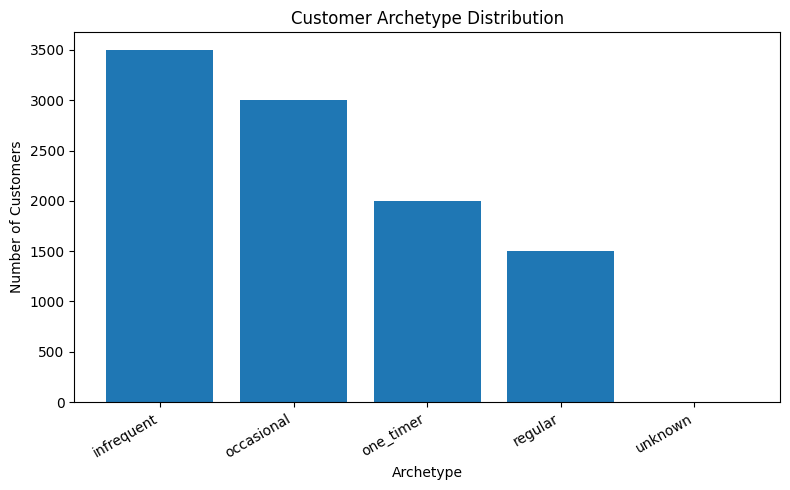

In [43]:
# Figure 1: Customer archetype distribution
counts = plot_df["archetype"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Customer Archetype Distribution")
plt.xlabel("Archetype")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
save_current_figure("fig_01_customer_archetype_distribution.png")

Saved: ../Module 4/figures\fig_02_price_tier_distribution.png


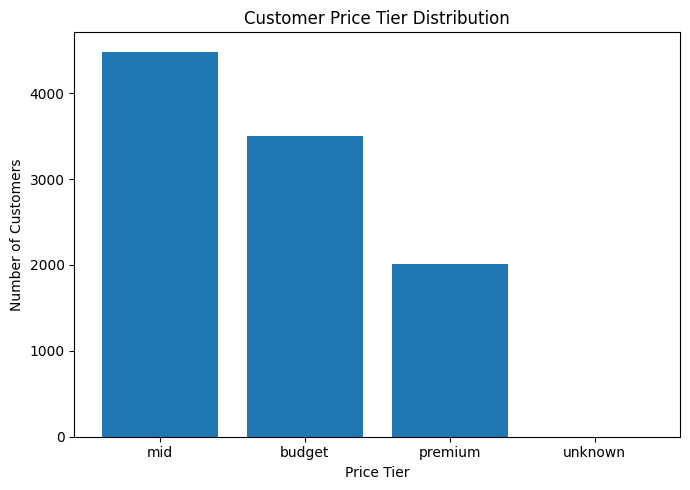

In [44]:
# Figure 2: Price tier distribution
counts = plot_df["price_tier"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Customer Price Tier Distribution")
plt.xlabel("Price Tier")
plt.ylabel("Number of Customers")
save_current_figure("fig_02_price_tier_distribution.png")

Saved: ../Module 4/figures\fig_03_expected_vs_actual_visits.png


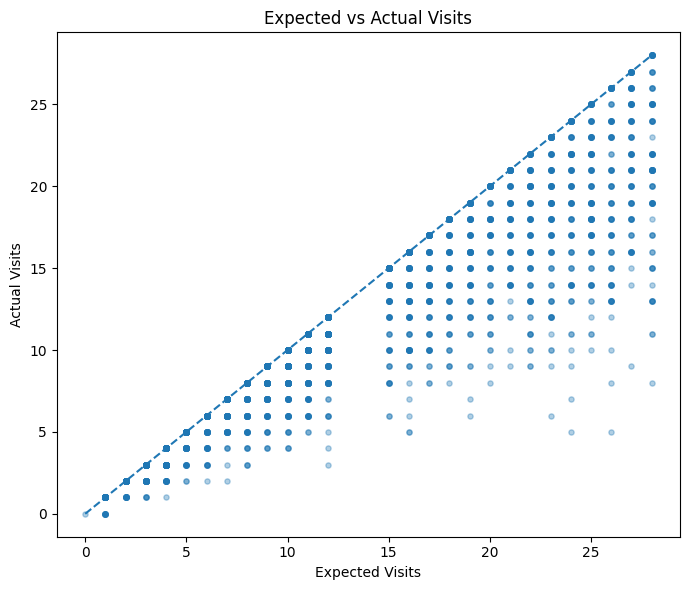

In [45]:
# Figure 3: Expected vs actual visits
plt.figure(figsize=(7, 6))
plt.scatter(plot_df["expected_visits"], plot_df["actual_visits"], alpha=0.35, s=14)
max_v = max(plot_df["expected_visits"].max(), plot_df["actual_visits"].max())
plt.plot([0, max_v], [0, max_v], linestyle="--")
plt.title("Expected vs Actual Visits")
plt.xlabel("Expected Visits")
plt.ylabel("Actual Visits")
save_current_figure("fig_03_expected_vs_actual_visits.png")

Saved: ../Module 4/figures\fig_04_visit_gap_distribution.png


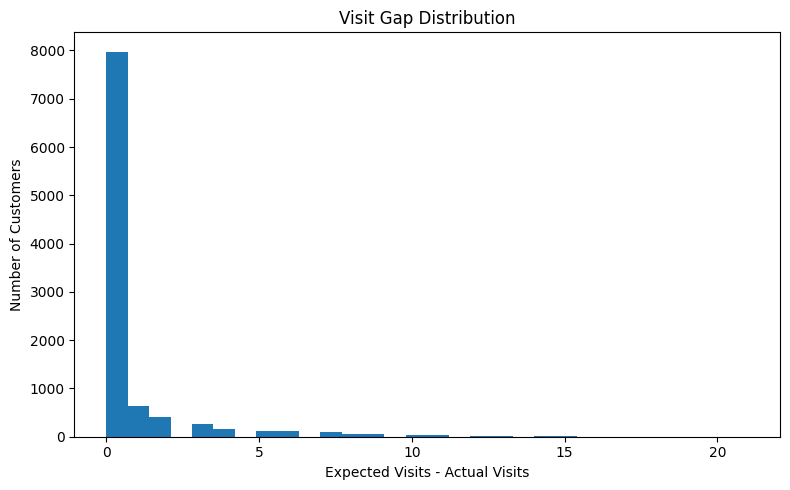

In [46]:
# Figure 4: Visit gap distribution
plt.figure(figsize=(8, 5))
plt.hist(plot_df["visit_gap"], bins=30)
plt.title("Visit Gap Distribution")
plt.xlabel("Expected Visits - Actual Visits")
plt.ylabel("Number of Customers")
save_current_figure("fig_04_visit_gap_distribution.png")

Saved: ../Module 4/figures\fig_05_rfm_distributions.png


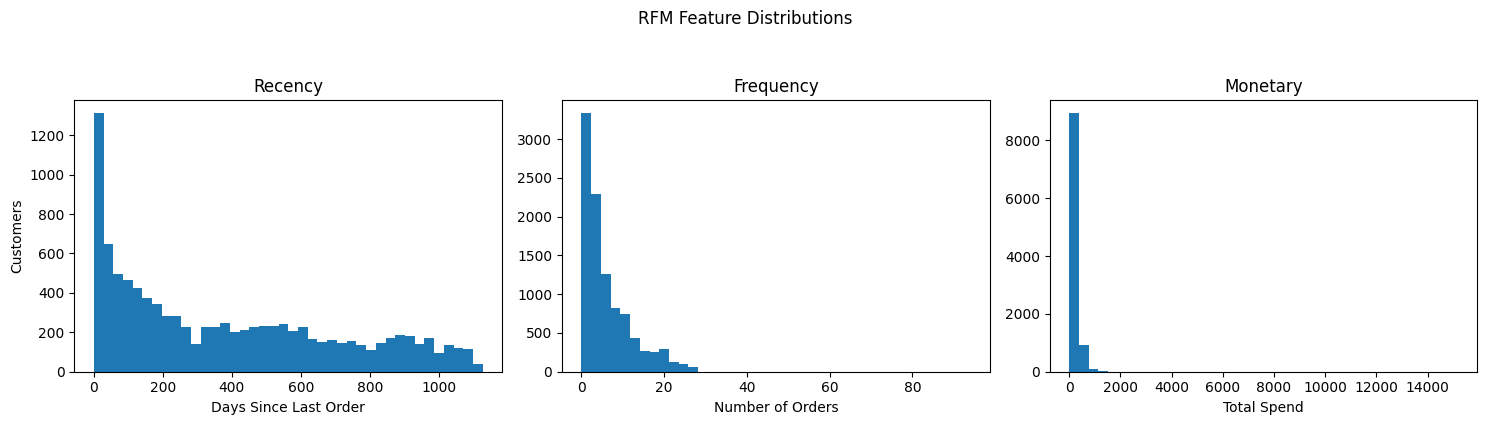

In [47]:
# Figure 5: RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(plot_df["recency"], bins=40)
axes[0].set_title("Recency")
axes[0].set_xlabel("Days Since Last Order")
axes[0].set_ylabel("Customers")

axes[1].hist(plot_df["frequency"], bins=40)
axes[1].set_title("Frequency")
axes[1].set_xlabel("Number of Orders")

axes[2].hist(plot_df["monetary"], bins=40)
axes[2].set_title("Monetary")
axes[2].set_xlabel("Total Spend")

fig.suptitle("RFM Feature Distributions", y=1.05)
save_current_figure("fig_05_rfm_distributions.png")

Saved: ../Module 4/figures\fig_06_monetary_by_archetype.png


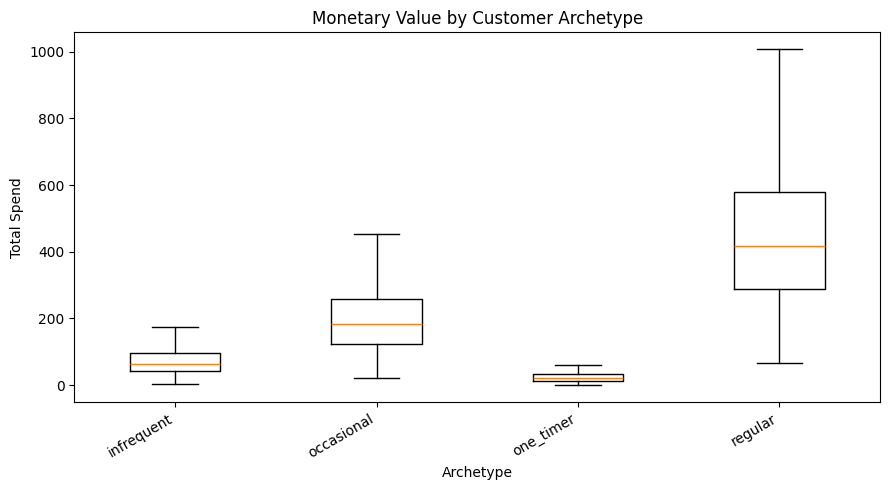

In [48]:
# Figure 6: Monetary value by archetype
archetypes = [a for a in plot_df["archetype"].dropna().unique() if a != "unknown"]
archetypes = sorted(archetypes)
data = [plot_df.loc[plot_df["archetype"] == a, "monetary"].dropna() for a in archetypes]

plt.figure(figsize=(9, 5))
plt.boxplot(data, labels=archetypes, showfliers=False)
plt.title("Monetary Value by Customer Archetype")
plt.xlabel("Archetype")
plt.ylabel("Total Spend")
plt.xticks(rotation=30, ha="right")
save_current_figure("fig_06_monetary_by_archetype.png")

Saved: ../Module 4/figures\fig_07_avg_order_value_by_price_tier.png


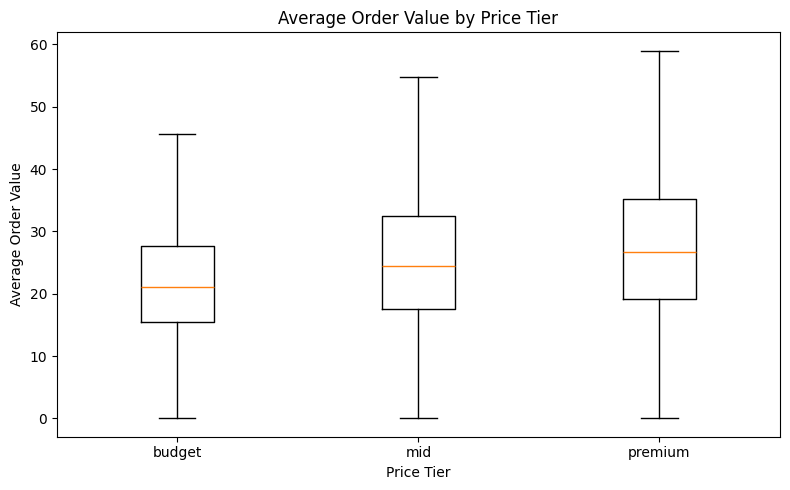

In [49]:
# Figure 7: Average order value by price tier
price_tiers = [p for p in plot_df["price_tier"].dropna().unique() if p != "unknown"]
price_tiers = sorted(price_tiers)
data = [plot_df.loc[plot_df["price_tier"] == p, "avg_order_value"].dropna() for p in price_tiers]

plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=price_tiers, showfliers=False)
plt.title("Average Order Value by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Average Order Value")
save_current_figure("fig_07_avg_order_value_by_price_tier.png")

Saved: ../Module 4/figures\fig_08_orders_by_hour.png


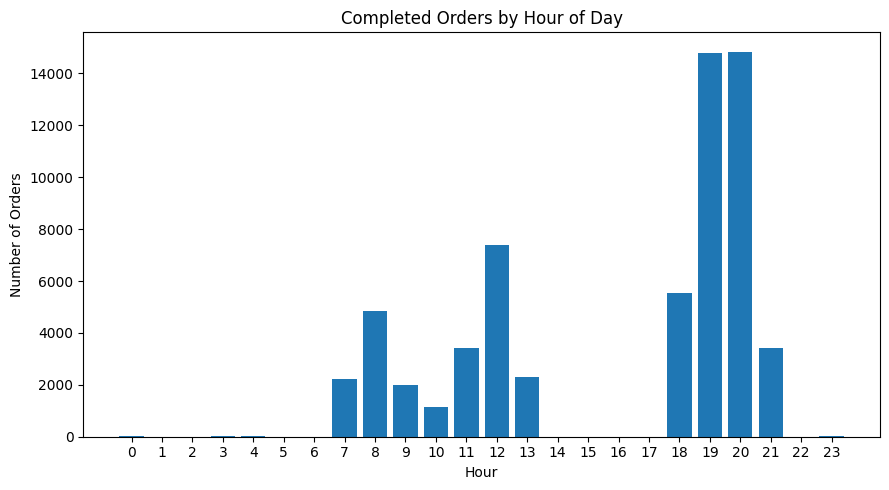

In [50]:
# Figure 8: Orders by hour
hour_counts = valid_orders_plot["order_hour"].value_counts().sort_index()
plt.figure(figsize=(9, 5))
plt.bar(hour_counts.index.astype(int), hour_counts.values)
plt.title("Completed Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(range(int(hour_counts.index.min()), int(hour_counts.index.max()) + 1))
save_current_figure("fig_08_orders_by_hour.png")

Saved: ../Module 4/figures\fig_09_orders_by_day_of_week.png


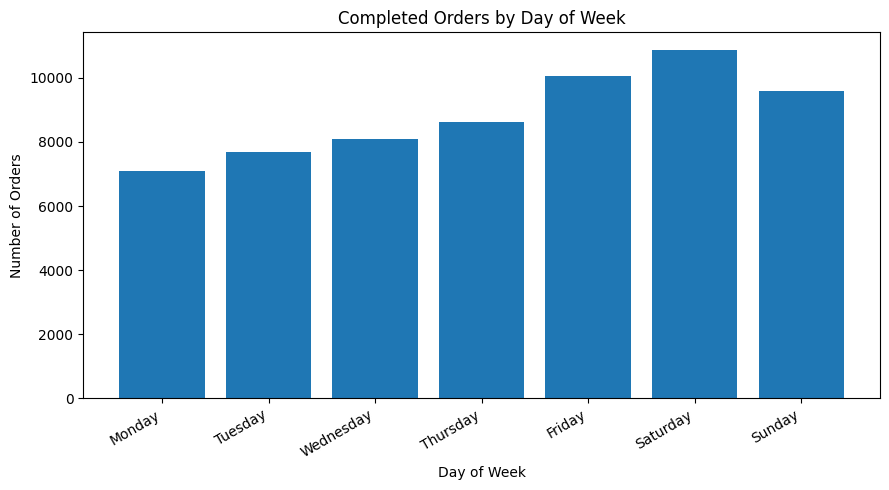

In [51]:
# Figure 9: Orders by day of week
ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = valid_orders_plot["day_of_week"].value_counts().reindex(ordered_days).fillna(0)
plt.figure(figsize=(9, 5))
plt.bar(day_counts.index, day_counts.values)
plt.title("Completed Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30, ha="right")
save_current_figure("fig_09_orders_by_day_of_week.png")

Saved: ../Module 4/figures\fig_10_revenue_by_section.png


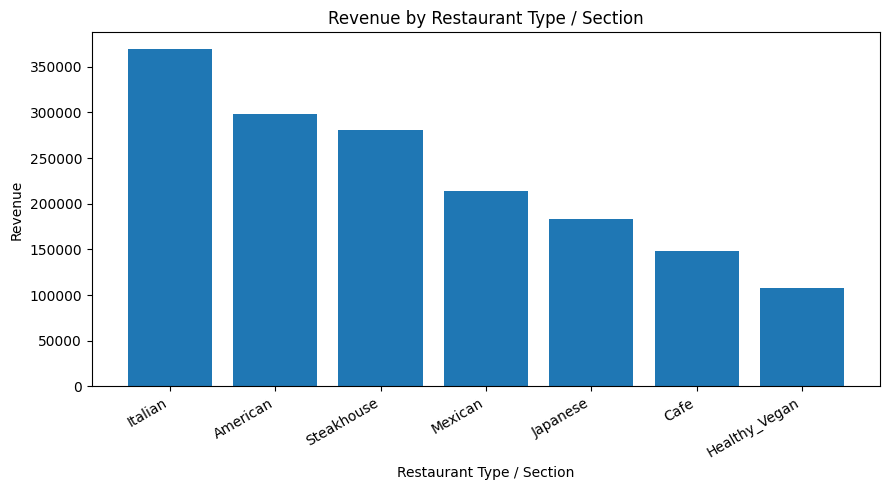

In [52]:
# Figure 10: Revenue by restaurant type / section
section_revenue = valid_lines_plot.groupby("restaurant_type")["line_total"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(section_revenue.index.astype(str), section_revenue.values)
plt.title("Revenue by Restaurant Type / Section")
plt.xlabel("Restaurant Type / Section")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
save_current_figure("fig_10_revenue_by_section.png")

Saved: ../Module 4/figures\fig_11_revenue_by_category.png


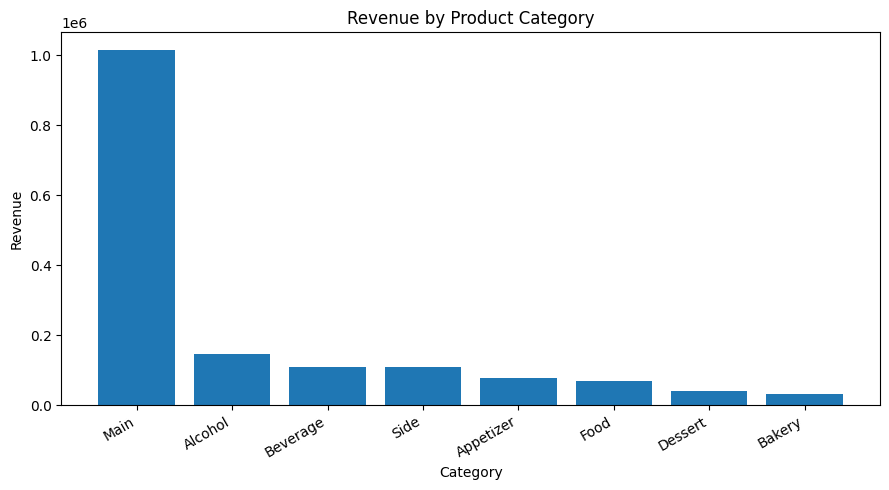

In [53]:
# Figure 11: Revenue by category
category_revenue = valid_lines_plot.groupby("category")["line_total"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(category_revenue.index.astype(str), category_revenue.values)
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
save_current_figure("fig_11_revenue_by_category.png")

Saved: ../Module 4/figures\fig_12_customer_feature_correlation_heatmap.png


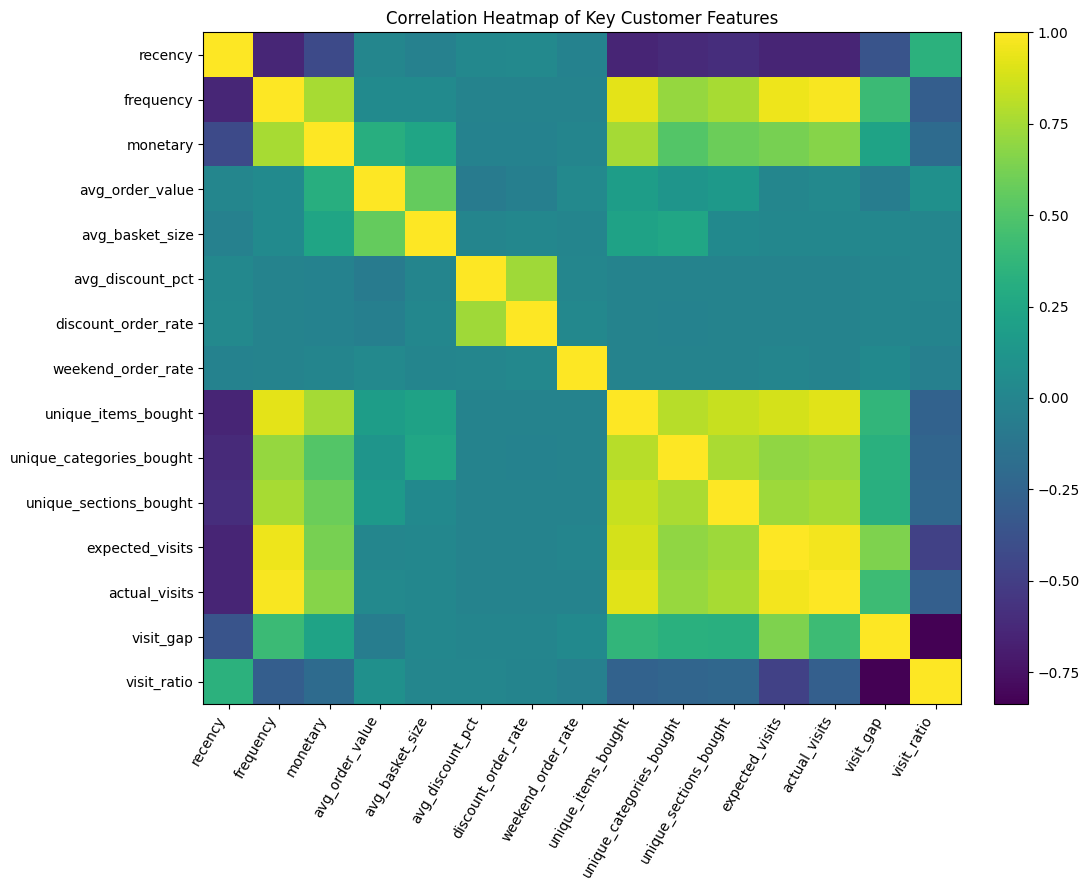

In [54]:
# Figure 12: Correlation heatmap of key numeric segmentation features
corr_cols = [
    "recency", "frequency", "monetary", "avg_order_value", "avg_basket_size",
    "avg_discount_pct", "discount_order_rate", "weekend_order_rate",
    "unique_items_bought", "unique_categories_bought", "unique_sections_bought",
    "expected_visits", "actual_visits", "visit_gap", "visit_ratio"
]
corr_cols = [c for c in corr_cols if c in plot_df.columns]
corr = plot_df[corr_cols].replace([np.inf, -np.inf], np.nan).fillna(0).corr()

plt.figure(figsize=(11, 9))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=60, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap of Key Customer Features")
save_current_figure("fig_12_customer_feature_correlation_heatmap.png")

## 12. Save final feature matrix

In [55]:
# Organize columns: identifiers/profile first, then engineered features
front_cols = [
    "customer_id", "profile_transaction_match", "archetype", "price_tier", "time_preference",
    "day_preference", "basket_size_bias", "preferred_sections", "preferred_categories",
    "expected_visits", "actual_visits", "visit_gap", "visit_ratio", "under_engaged_flag"
]

front_cols = [c for c in front_cols if c in customer_features.columns]
other_cols = [c for c in customer_features.columns if c not in front_cols]
customer_features = customer_features[front_cols + other_cols]

features_path = os.path.join(FEATURE_DIR, "customer_features.csv")
customer_features.to_csv(features_path, index=False)

# Also save a compact data dictionary for Notebook 2
feature_summary = {
    "n_rows": int(customer_features.shape[0]),
    "n_columns": int(customer_features.shape[1]),
    "source_files": [CUSTOMERS_PATH, TRANSACTIONS_PATH],
    "output_file": features_path,
    "reference_date_for_recency": str(reference_date),
    "figures_dir": FIGURE_DIR,
}

summary_path = os.path.join(REPORT_DIR, "notebook1_feature_engineering_summary.json")

with open(summary_path, "w") as f:
    json.dump(feature_summary, f, indent=2)

print("Saved customer feature matrix:", features_path)
print("Saved summary JSON:", summary_path)
print("Saved figures in:", FIGURE_DIR)

display(customer_features.head())

Saved customer feature matrix: ../Module 4\customer_features.csv
Saved summary JSON: ../Module 4\notebook1_feature_engineering_summary.json
Saved figures in: ../Module 4/figures


,customer_id,profile_transaction_match,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,visit_gap,visit_ratio,under_engaged_flag,last_order_date,first_order_date,frequency,monetary,recency,customer_tenure_days,monetary_per_order,R_score,F_score,M_score,rfm_score,rfm_code,total_orders,avg_order_value,median_order_value,max_order_value,avg_basket_size,median_basket_size,avg_unique_items_per_order,avg_categories_per_order,avg_item_price,avg_discount_pct,discount_order_rate,total_discount_amount_est,payment_share_card,payment_share_cash,payment_share_mobile,preferred_payment_method,avg_order_hour,std_order_hour,weekend_order_rate,dow_share_friday,dow_share_monday,dow_share_saturday,dow_share_sunday,dow_share_thursday,dow_share_tuesday,dow_share_wednesday,meal_share_dinner,meal_share_late_night,meal_share_lunch,meal_share_morning,dominant_meal_period,dominant_day_of_week,category_share_alcohol,category_share_appetizer,category_share_bakery,category_share_beverage,category_share_dessert,category_share_food,category_share_main,category_share_side,section_share_american,section_share_cafe,section_share_healthy_vegan,section_share_italian,section_share_japanese,section_share_mexican,section_share_steakhouse,unique_items_bought,unique_categories_bought,unique_sections_bought,dominant_category,dominant_section
0,5485,both,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2.0,2.0,0.0,1.000000,0,2025-11-09 19:30:00,2025-05-13 21:00:00,2.0,136.00,53.0,179.0,68.000000,5,2,4,11,524,2.0,68.000000,68.000,82.0,2.5,2.5,2.5,2.00,27.166667,0.0,0.00,0.0000,0.500,0.5000,0.0000,card,20.000,1.414214,0.5000,0.0000,0.0000,0.00,0.5000,0.0000,0.500,0.000,1.00,0.0,0.0,0.00,dinner,Sunday,0.110294,0.117647,0.000000,0.000000,0.000000,0.000000,0.772059,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,5.0,3.0,1.0,Main,Steakhouse
1,7761,both,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4.0,4.0,0.0,1.000000,0,2025-02-11 19:30:00,2024-04-14 19:00:00,4.0,189.00,324.0,303.0,47.250000,3,3,4,10,334,4.0,47.250000,38.000,83.0,4.0,4.0,4.0,2.25,11.868750,0.0,0.00,0.0000,0.500,0.2500,0.2500,card,19.250,0.500000,0.2500,0.5000,0.0000,0.00,0.2500,0.0000,0.250,0.000,1.00,0.0,0.0,0.00,dinner,Friday,0.169312,0.000000,0.000000,0.000000,0.000000,0.000000,0.682540,0.148148,0.000000,0.000000,0.0,0.000000,0.000000,0.560847,0.439153,12.0,3.0,2.0,Main,Mexican
2,1774,both,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5.0,5.0,0.0,1.000000,0,2024-08-07 12:30:00,2023-02-01 12:30:00,5.0,128.30,512.0,553.0,25.660000,2,3,3,8,233,5.0,25.660000,25.000,32.3,4.0,4.0,4.0,2.60,6.650000,1.0,0.20,1.7000,0.800,0.0000,0.2000,card,11.800,0.447214,0.2000,0.0000,0.0000,0.20,0.0000,0.0000,0.200,0.600,0.00,0.0,1.0,0.00,lunch,Wednesday,0.000000,0.000000,0.000000,0.139361,0.038971,0.000000,0.755417,0.066251,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,12.0,4.0,1.0,Main,American
3,3417,both,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6.0,6.0,0.0,1.000000,0,2025-10-17 20:00:00,2024-02-24 09:00:00,5.0,148.75,76.0,601.0,29.750000,4,3,4,11,434,5.0,29.750000,25.500,50.0,3.4,4.0,3.4,2.20,10.707500,0.0,0.00,0.0000,0.200,0.6000,0.2000,cash,15.000,6.000000,0.6000,0.4000,0.0000,0.40,0.2000,0.0000,0.000,0.000,0.60,0.0,0.0,0.40,dinner,Friday,0.100840,0.060504,0.040336,0.126050,0.000000,0.134454,0.537815,0.000000,0.137815,0.300840,0.0,0.000000,0.225210,0.000000,0.336134,17.0,6.0,4.0,Main,Steakhouse
4,447,both,regular,premium,morning,any,medium,Cafe,"Appetizer,Food,Dessert",22.0,16.0,6.0,0.727273,1,2025-12-05 19:00:00,2023-01-08 20:00:00,16.0,288.87,27.0,1061.0,18.054375,5,5,5,15,555,16.0,18.054375,16.625,38.0,3.0,3.0,3.0,2.25,6.527083,2.5,0.25,7.6375,0.625,0.3125,0.0625,card,11.125,5.226535,0.4375,0.1875,0.0625,0.25,0.1875,0.0625,0.125,0.125,0.25,0.0,0.0,0.75,morning,Saturday,0.034618,0.000000,0.137121,0.1

## 13. Final checks for Notebook 2

Notebook 2 can now use `customer_features.csv` to build:
- RFM rule-based segmentation
- K-Means clustering
- Hierarchical clustering validation
- Hybrid RFM + behavioral segmentation

In [56]:
print("Final dataset shape:", customer_features.shape)
print("Unique customers:", customer_features["customer_id"].nunique())

print("\nImportant numeric features:")
display(customer_features[
    [
        "recency", "frequency", "monetary", "avg_order_value", "avg_basket_size",
        "avg_discount_pct", "weekend_order_rate", "visit_gap", "visit_ratio"
    ]
].describe())

print("\nFigure files:")
for fig_name in sorted(os.listdir(FIGURE_DIR)):
    if fig_name.startswith("fig_") and fig_name.endswith(".png"):
        print(fig_name)

Final dataset shape: (10001, 78)
Unique customers: 10001

Important numeric features:


,recency,frequency,monetary,avg_order_value,avg_basket_size,avg_discount_pct,weekend_order_rate,visit_gap,visit_ratio
count,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
mean,384.117388,6.197980,160.172162,25.329531,2.803359,1.617940,0.334883,0.723828,0.952401
std,326.350516,5.876257,228.657435,12.410557,0.819163,3.890366,0.316730,2.017256,0.116258
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,88.000000,2.000000,40.800000,16.987500,2.250000,0.000000,0.000000,0.000000,1.000000
50%,312.000000,4.000000,95.500000,23.400000,2.833333,0.000000,0.285714,0.000000,1.000000
75%,623.000000,9.000000,215.130000,31.307000,3.285714,1.923077,0.500000,0.000000,1.000000
max,1126.000000,94.000000,15189.000000,161.585106,18.148936,90.000000,1.000000,21.000000,1.000000



Figure files:
fig_01_customer_archetype_distribution.png
fig_02_price_tier_distribution.png
fig_03_expected_vs_actual_visits.png
fig_04_visit_gap_distribution.png
fig_05_rfm_distributions.png
fig_06_monetary_by_archetype.png
fig_07_avg_order_value_by_price_tier.png
fig_08_orders_by_hour.png
fig_09_orders_by_day_of_week.png
fig_10_revenue_by_section.png
fig_11_revenue_by_category.png
fig_12_customer_feature_correlation_heatmap.png
